# scDeoxys 基础示例

本 notebook 演示了 scDeoxys 的完整工作流程：

1. 生成合成 Swiss Roll Simplex 数据
2. 训练 ParetoVAE 模型
3. 可视化结果
4. 计算评估指标

每个步骤都可以单独运行，方便检查运行时的内部状态。

In [2]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import torch
import json

import scanpy as sc

from scipy.stats import pearsonr
from scipy.optimize import linear_sum_assignment

from scdeoxys import ParetoVAE, generate_swiss_roll_simplex, Trainer
from scdeoxys.plotting import plot_simplex_projection, plot_training_curves, plot_comparison

print("所有库导入成功！")

所有库导入成功！


In [3]:
# 设置随机种子以确保可重复性
np.random.seed(42)
torch.manual_seed(42)

print("随机种子已设置：42")

随机种子已设置：42


## 1. 生成合成数据

生成 Swiss Roll Simplex 模拟数据，并检查数据格式。

In [4]:
# 生成合成数据
print("正在生成 Swiss Roll Simplex 数据...")
adata = generate_swiss_roll_simplex(
    n_cells=1000,
    n_genes=500,
    n_archetypes=3,
    alpha=1.0,
    curvature=1.0,
    theta=10.0,
    seed=42,
)

# 提取数据
x_train = adata.layers["counts"]
z_true = adata.obsm["X_true_simplex"]
archetypes = adata.uns["scdeoxys_synthetic"]["archetypes"]
swiss_roll_3d = adata.obsm["X_swiss_roll_3d"]
color_param = adata.obs["color_param"].to_numpy()

print(f"✓ 生成了 {x_train.shape[0]} 个细胞，{x_train.shape[1]} 个基因")
print(f"✓ 原型数量: {z_true.shape[1]}")
print(f"✓ 每个细胞的平均计数: {x_train.mean():.2f}")

正在生成 Swiss Roll Simplex 数据...
✓ 生成了 1000 个细胞，500 个基因
✓ 原型数量: 3
✓ 每个细胞的平均计数: 9.45


In [5]:
adata

AnnData object with n_obs × n_vars = 1000 × 500
    obs: 'color_param'
    uns: 'scdeoxys_synthetic'
    obsm: 'X_true_simplex', 'X_swiss_roll_3d'
    layers: 'counts'

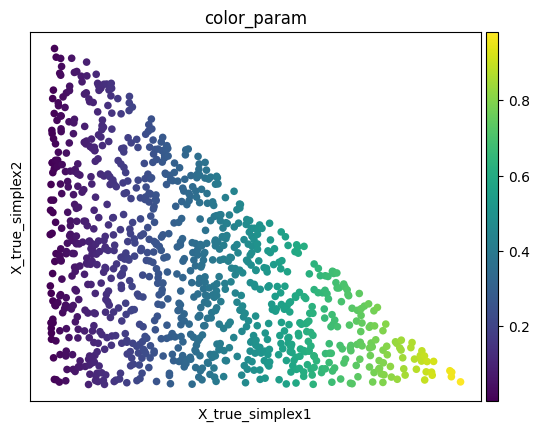

In [6]:
sc.pl.embedding(adata, basis="X_true_simplex", color="color_param")

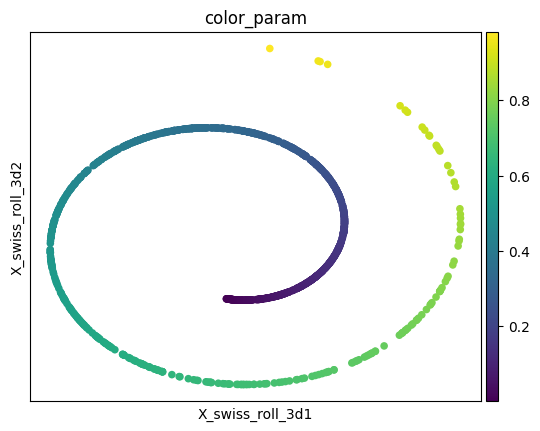

In [7]:
sc.pl.embedding(adata, basis="X_swiss_roll_3d", color="color_param")

### 检查生成数据的格式和统计信息

In [7]:
# 检查数据格式
print("=" * 60)
print("数据格式检查")
print("=" * 60)

print(f"\n1. 计数矩阵 (x_train):")
print(f"   - 形状: {x_train.shape}")
print(f"   - 数据类型: {x_train.dtype}")
print(f"   - 最小值: {x_train.min()}")
print(f"   - 最大值: {x_train.max()}")
print(f"   - 平均值: {x_train.mean():.4f}")
print(f"   - 标准差: {x_train.std():.4f}")
print(f"   - 零值比例: {(x_train == 0).sum() / x_train.size * 100:.2f}%")

print(f"\n2. 真实 simplex 坐标 (z_true):")
print(f"   - 形状: {z_true.shape}")
print(f"   - 数据类型: {z_true.dtype}")
print(f"   - 最小值: {z_true.min():.4f}")
print(f"   - 最大值: {z_true.max():.4f}")
print(f"   - 每行和（应该接近1，因为是simplex）: {z_true.sum(axis=1)[:5]}...")
print(f"   - 每行和的范围: [{z_true.sum(axis=1).min():.4f}, {z_true.sum(axis=1).max():.4f}]")

print(f"\n3. 原型 (archetypes):")
print(f"   - 形状: {archetypes.shape}")
print(f"   - 数据类型: {archetypes.dtype}")

print(f"\n4. Swiss Roll 3D 坐标:")
print(f"   - 形状: {swiss_roll_3d.shape}")

print(f"\n5. 颜色参数:")
print(f"   - 形状: {color_param.shape}")
print(f"   - 范围: [{color_param.min():.4f}, {color_param.max():.4f}]")

数据格式检查

1. 计数矩阵 (x_train):
   - 形状: (1000, 500)
   - 数据类型: float32
   - 最小值: 0.0
   - 最大值: 272.0
   - 平均值: 9.4508
   - 标准差: 11.9833
   - 零值比例: 15.89%

2. 真实 simplex 坐标 (z_true):
   - 形状: (1000, 3)
   - 数据类型: float64
   - 最小值: 0.0000
   - 最大值: 0.9821
   - 每行和（应该接近1，因为是simplex）: [1. 1. 1. 1. 1.]...
   - 每行和的范围: [1.0000, 1.0000]

3. 原型 (archetypes):
   - 形状: (3, 500)
   - 数据类型: float64

4. Swiss Roll 3D 坐标:
   - 形状: (1000, 3)

5. 颜色参数:
   - 形状: (1000,)
   - 范围: [0.0000, 0.9821]


### 可视化生成数据的分布

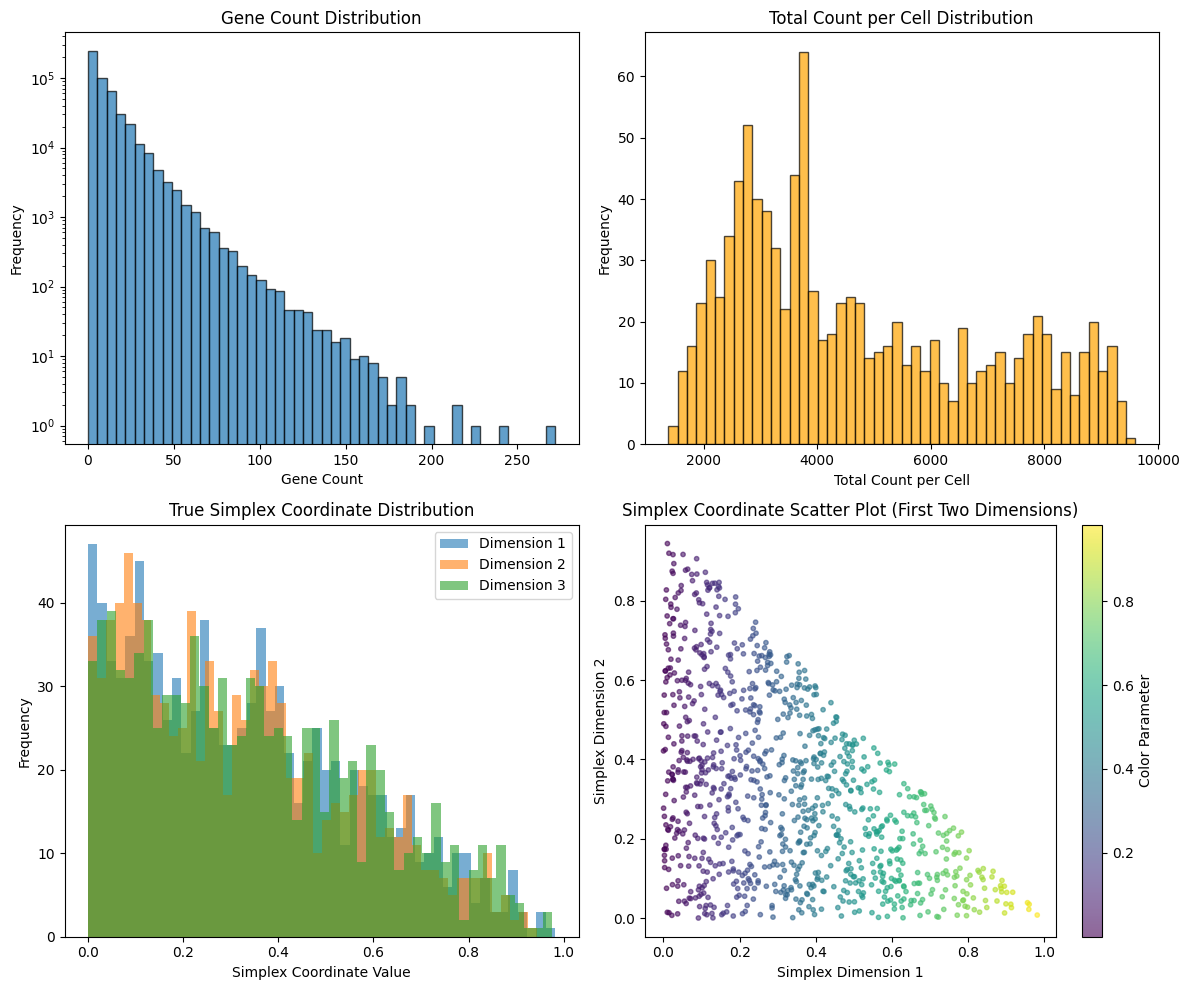

数据分布可视化完成！


In [8]:
# 可视化计数矩阵的分布
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 计数分布直方图
axes[0, 0].hist(x_train.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Gene Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Gene Count Distribution')
axes[0, 0].set_yscale('log')

# 2. 每个细胞的总计数
cell_totals = x_train.sum(axis=1)
axes[0, 1].hist(cell_totals, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Total Count per Cell')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Total Count per Cell Distribution')

# 3. Simplex 坐标分布（每个维度的直方图）
for i in range(z_true.shape[1]):
    axes[1, 0].hist(z_true[:, i], bins=50, alpha=0.6, label=f'Dimension {i+1}')
axes[1, 0].set_xlabel('Simplex Coordinate Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('True Simplex Coordinate Distribution')
axes[1, 0].legend()

# 4. Simplex 坐标的散点图（前两个维度）
scatter = axes[1, 1].scatter(z_true[:, 0], z_true[:, 1], c=color_param, 
                             cmap='viridis', alpha=0.6, s=10)
axes[1, 1].set_xlabel('Simplex Dimension 1')
axes[1, 1].set_ylabel('Simplex Dimension 2')
axes[1, 1].set_title('Simplex Coordinate Scatter Plot (First Two Dimensions)')
plt.colorbar(scatter, ax=axes[1, 1], label='Color Parameter')

plt.tight_layout()
plt.show()

print("数据分布可视化完成！")

### 可视化 Swiss Roll 3D 结构

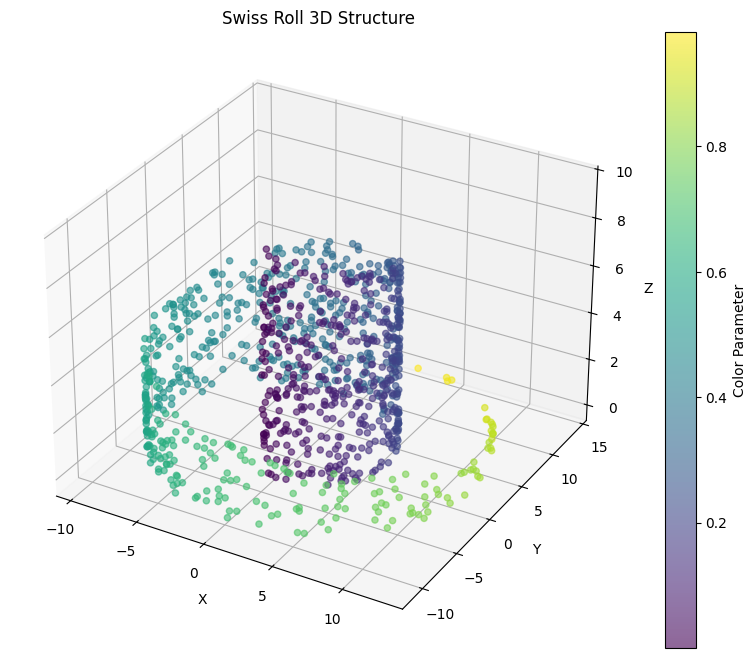

Swiss Roll 3D 可视化完成！


In [9]:
# 可视化 Swiss Roll 的 3D 结构
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 使用颜色参数来着色
scatter = ax.scatter(swiss_roll_3d[:, 0], swiss_roll_3d[:, 1], swiss_roll_3d[:, 2],
                     c=color_param, cmap='viridis', s=20, alpha=0.6)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Swiss Roll 3D Structure')
plt.colorbar(scatter, label='Color Parameter')

plt.show()
print("Swiss Roll 3D 可视化完成！")

## 2. 创建模型

创建 ParetoVAE 模型并检查其结构。

In [10]:
# 创建模型
print("正在创建 ParetoVAE 模型...")
model = ParetoVAE(
    n_genes=x_train.shape[1],
    n_archetypes=3,
    hidden_dims=[512, 256, 128],
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ 模型创建成功")
print(f"✓ 总参数量: {total_params:,}")
print(f"✓ 可训练参数量: {trainable_params:,}")

# 显示模型结构
print("\n模型结构:")
print(model)

正在创建 ParetoVAE 模型...
✓ 模型创建成功
✓ 总参数量: 847,214
✓ 可训练参数量: 847,214

模型结构:
ParetoVAE(
  (encoder): Encoder(
    (hidden): Sequential(
      (0): Linear(in_features=500, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=256, out_features=128, bias=True)
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
    )
    (fc_mu): Linear(in_features=128, out_features=3, bias=True)
    (fc_logvar): Linear(in_features=128, out_features=3, bias=True)
  )
  (decoder): Decoder(
    (hidden): Sequential(
      (0): Linear(in_features=3, 

## 3. 训练模型

训练模型并监控训练过程。

In [11]:
# 创建训练器
trainer = Trainer(
    model,
    learning_rate=1e-3,
    beta_warmup_epochs=100,
    beta_min=0.0,
    beta_max=1.0,
    free_bits=0.1,
)

print("训练器创建成功！")
print(f"学习率: {trainer.learning_rate}")
print(f"Beta warmup epochs: {trainer.beta_warmup_epochs}")
print(f"Beta 范围: [{trainer.beta_min}, {trainer.beta_max}]")
print(f"Free bits: {trainer.free_bits}")

训练器创建成功！
学习率: 0.001
Beta warmup epochs: 100
Beta 范围: [0.0, 1.0]
Free bits: 0.1


In [12]:
# 开始训练
print("开始训练模型...")
print("=" * 60)

history = trainer.train(
    adata,
    n_epochs=250,
    batch_size=128,
    verbose=True,
)

print("\n" + "=" * 60)
print("训练完成！")
print(f"✓ 最终总损失: {history['total_loss'][-1]:.4f}")
print(f"✓ 最终重构损失: {history['recon_loss'][-1]:.4f}")
print(f"✓ 最终 KL 损失: {history['kl_loss'][-1]:.4f}")

开始训练模型...


Training: 100%|██████████| 250/250 [00:51<00:00,  4.85it/s, loss=1343.4474, recon=1334.6122, kl=8.8352, beta=1.00]


训练完成！
✓ 最终总损失: 1343.4474
✓ 最终重构损失: 1334.6122
✓ 最终 KL 损失: 8.8352


### 检查训练历史

In [13]:
# 检查训练历史的格式
print("训练历史键:", list(history.keys()))
print(f"\n每个键的长度:")
for key in history.keys():
    print(f"  - {key}: {len(history[key])}")

# 显示最后几个 epoch 的损失值
print(f"\n最后 5 个 epoch 的损失:")
print(f"{'Epoch':<10} {'Total Loss':<15} {'Recon Loss':<15} {'KL Loss':<15}")
print("-" * 55)
for i in range(max(0, len(history['total_loss']) - 5), len(history['total_loss'])):
    print(f"{i+1:<10} {history['total_loss'][i]:<15.4f} {history['recon_loss'][i]:<15.4f} {history['kl_loss'][i]:<15.4f}")

训练历史键: ['total_loss', 'recon_loss', 'kl_loss', 'beta']

每个键的长度:
  - total_loss: 250
  - recon_loss: 250
  - kl_loss: 250
  - beta: 250

最后 5 个 epoch 的损失:
Epoch      Total Loss      Recon Loss      KL Loss        
-------------------------------------------------------
246        1343.6245       1334.8011       8.8234         
247        1342.2217       1333.4558       8.7660         
248        1344.4628       1335.7081       8.7547         
249        1343.9431       1335.1301       8.8130         
250        1343.4474       1334.6122       8.8352         


## 4. 编码数据

将数据编码到 simplex 空间。

In [14]:
# 编码数据到 simplex 空间
print("正在编码数据到 simplex 空间...")
trainer.encode(adata)
z_scdeoxys = adata.obsm["X_scdeoxys"]

print(f"✓ 编码完成")
print(f"✓ 编码后的形状: {z_scdeoxys.shape}")
print(f"✓ 数据类型: {z_scdeoxys.dtype}")
print(f"✓ 最小值: {z_scdeoxys.min():.4f}")
print(f"✓ 最大值: {z_scdeoxys.max():.4f}")
print(f"✓ 平均值: {z_scdeoxys.mean(axis=0)}")
print(f"✓ 每行和的范围: [{z_scdeoxys.sum(axis=1).min():.4f}, {z_scdeoxys.sum(axis=1).max():.4f}]")

正在编码数据到 simplex 空间...
✓ 编码完成
✓ 编码后的形状: (1000, 3)
✓ 数据类型: float32
✓ 最小值: 0.0119
✓ 最大值: 0.9088
✓ 平均值: [0.35698858 0.3427434  0.30026835]
✓ 每行和的范围: [1.0000, 1.0000]


### 比较预测和真实的 simplex 坐标

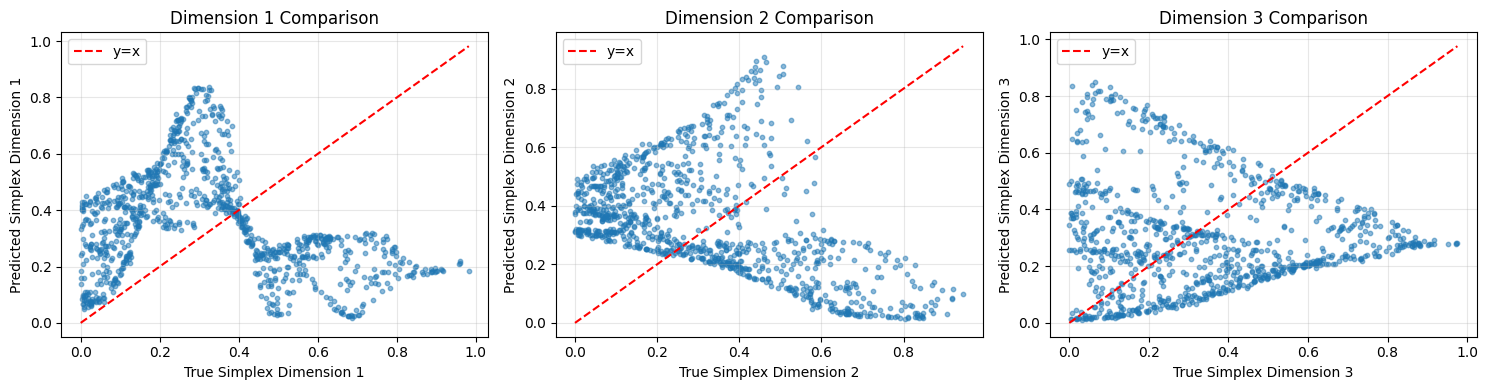

Simplex 坐标对比可视化完成！


In [15]:
# 可视化预测和真实的 simplex 坐标对比
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].scatter(z_true[:, i], z_scdeoxys[:, i], alpha=0.5, s=10)
    axes[i].plot([z_true[:, i].min(), z_true[:, i].max()], 
                 [z_true[:, i].min(), z_true[:, i].max()], 
                 'r--', label='y=x')
    axes[i].set_xlabel(f'True Simplex Dimension {i+1}')
    axes[i].set_ylabel(f'Predicted Simplex Dimension {i+1}')
    axes[i].set_title(f'Dimension {i+1} Comparison')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Simplex 坐标对比可视化完成！")

## 5. 计算评估指标

定义评估函数并计算指标。

In [15]:
def compute_simplex_metrics(z_pred, z_true):
    """
    计算比较预测和真实 simplex 坐标的指标。

    Args:
        z_pred: 预测的 simplex 坐标，形状 (n_cells, n_archetypes)
        z_true: 真实的 simplex 坐标，形状 (n_cells, n_archetypes)

    Returns:
        metrics: 评估指标字典
    """
    n_archetypes = z_true.shape[1]

    # 每个维度的 Pearson 相关系数（未对齐）
    correlations_raw = []
    for k in range(n_archetypes):
        r, _ = pearsonr(z_pred[:, k], z_true[:, k])
        correlations_raw.append(r)

    # 原始 MSE 和 simplex 距离（未对齐）
    mse_raw = np.mean((z_pred - z_true) ** 2)
    simplex_dist_raw = np.mean(np.sum(np.abs(z_pred - z_true), axis=1))

    # 使用匈牙利算法找到最优对齐
    # cost_matrix[i, j] = -|corr(z_pred[:, i], z_true[:, j])|
    # 匹配: z_pred[:, row_ind[k]] 对应 z_true[:, col_ind[k]]
    cost_matrix = np.zeros((n_archetypes, n_archetypes))
    for i in range(n_archetypes):
        for j in range(n_archetypes):
            r, _ = pearsonr(z_pred[:, i], z_true[:, j])
            cost_matrix[i, j] = -abs(r)

    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    # 构建排列: perm[j] = i 表示 z_pred[:, i] 映射到 z_true[:, j]
    perm = np.zeros(n_archetypes, dtype=int)
    for k in range(len(row_ind)):
        perm[col_ind[k]] = row_ind[k]

    # 重新排列 z_pred 以对齐 z_true
    z_pred_aligned = z_pred[:, perm]

    # 对齐后的相关系数
    correlations_aligned = []
    for k in range(n_archetypes):
        r, _ = pearsonr(z_pred_aligned[:, k], z_true[:, k])
        correlations_aligned.append(r)

    # 对齐后的 MSE 和 simplex 距离
    mse_aligned = np.mean((z_pred_aligned - z_true) ** 2)
    simplex_dist_aligned = np.mean(np.sum(np.abs(z_pred_aligned - z_true), axis=1))

    return {
        "correlations_raw": correlations_raw,
        "correlations_aligned": correlations_aligned,
        "mean_correlation_raw": np.mean(correlations_raw),
        "mean_correlation_aligned": np.mean(correlations_aligned),
        "mse_raw": mse_raw,
        "mse_aligned": mse_aligned,
        "simplex_distance_raw": simplex_dist_raw,
        "simplex_distance_aligned": simplex_dist_aligned,
        "alignment_perm": perm.tolist(),
    }

print("评估函数定义完成！")

评估函数定义完成！


In [16]:
# 计算评估指标
print("正在计算评估指标...")
metrics = compute_simplex_metrics(z_scdeoxys, z_true)

# 添加训练指标
metrics["final_total_loss"] = history["total_loss"][-1]
metrics["final_recon_loss"] = history["recon_loss"][-1]
metrics["final_kl_loss"] = history["kl_loss"][-1]

print("✓ 指标计算完成")

# 打印摘要
print(f"\n{'='*60}")
print("评估结果摘要")
print(f"{'='*60}")

print(f"\n原始（未对齐）:")
print(f"  - 相关系数: {[f'{r:.3f}' for r in metrics['correlations_raw']]}")
print(f"  - 平均相关系数: {metrics['mean_correlation_raw']:.3f}")
print(f"  - MSE: {metrics['mse_raw']:.4f}")
print(f"  - Simplex 距离 (L1): {metrics['simplex_distance_raw']:.4f}")

print(f"\n对齐后（最优排列 {metrics['alignment_perm']}）:")
print(f"  - 相关系数: {[f'{r:.3f}' for r in metrics['correlations_aligned']]}")
print(f"  - 平均相关系数: {metrics['mean_correlation_aligned']:.3f}")
print(f"  - MSE: {metrics['mse_aligned']:.4f}")
print(f"  - Simplex 距离 (L1): {metrics['simplex_distance_aligned']:.4f}")

print(f"\n训练损失:")
print(f"  - 最终总损失: {metrics['final_total_loss']:.4f}")
print(f"  - 最终重构损失: {metrics['final_recon_loss']:.4f}")
print(f"  - 最终 KL 损失: {metrics['final_kl_loss']:.4f}")

正在计算评估指标...
✓ 指标计算完成

评估结果摘要

原始（未对齐）:
  - 相关系数: ['-0.279', '-0.490', '-0.046']
  - 平均相关系数: -0.272
  - MSE: 0.1136
  - Simplex 距离 (L1): 0.8551

对齐后（最优排列 [1, 2, 0]）:
  - 相关系数: ['0.643', '0.422', '0.209']
  - 平均相关系数: 0.425
  - MSE: 0.0526
  - Simplex 距离 (L1): 0.5318

训练损失:
  - 最终总损失: 1343.4474
  - 最终重构损失: 1334.6122
  - 最终 KL 损失: 8.8352


In [ ]:
# 保存指标到文件
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("✓ 指标已保存到 metrics.json")

## 6. 可视化结果

生成训练曲线和对比图。

正在生成训练曲线...
✓ Training curves saved to training_curves.png


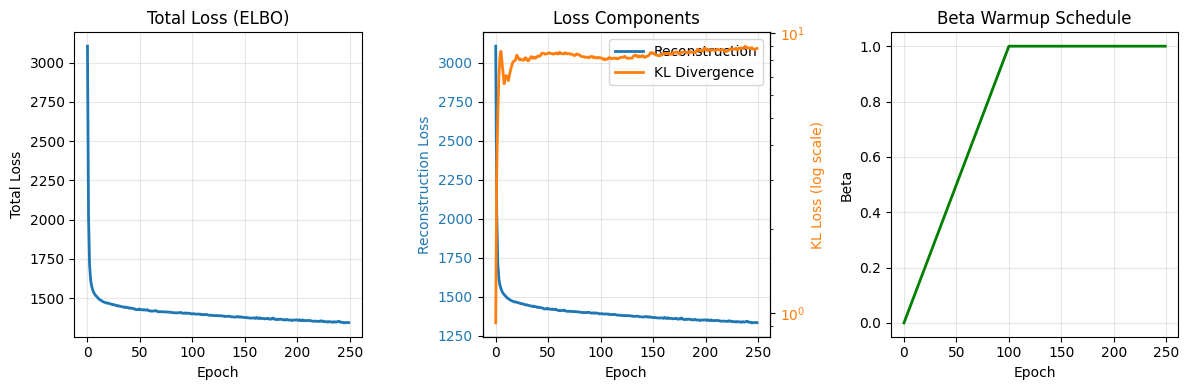

In [17]:
# 绘制训练曲线
print("正在生成训练曲线...")
fig1 = plot_training_curves(adata)
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
print("✓ Training curves saved to training_curves.png")
plt.show()

正在生成对比图...
✓ Comparison plot saved to comparison.png


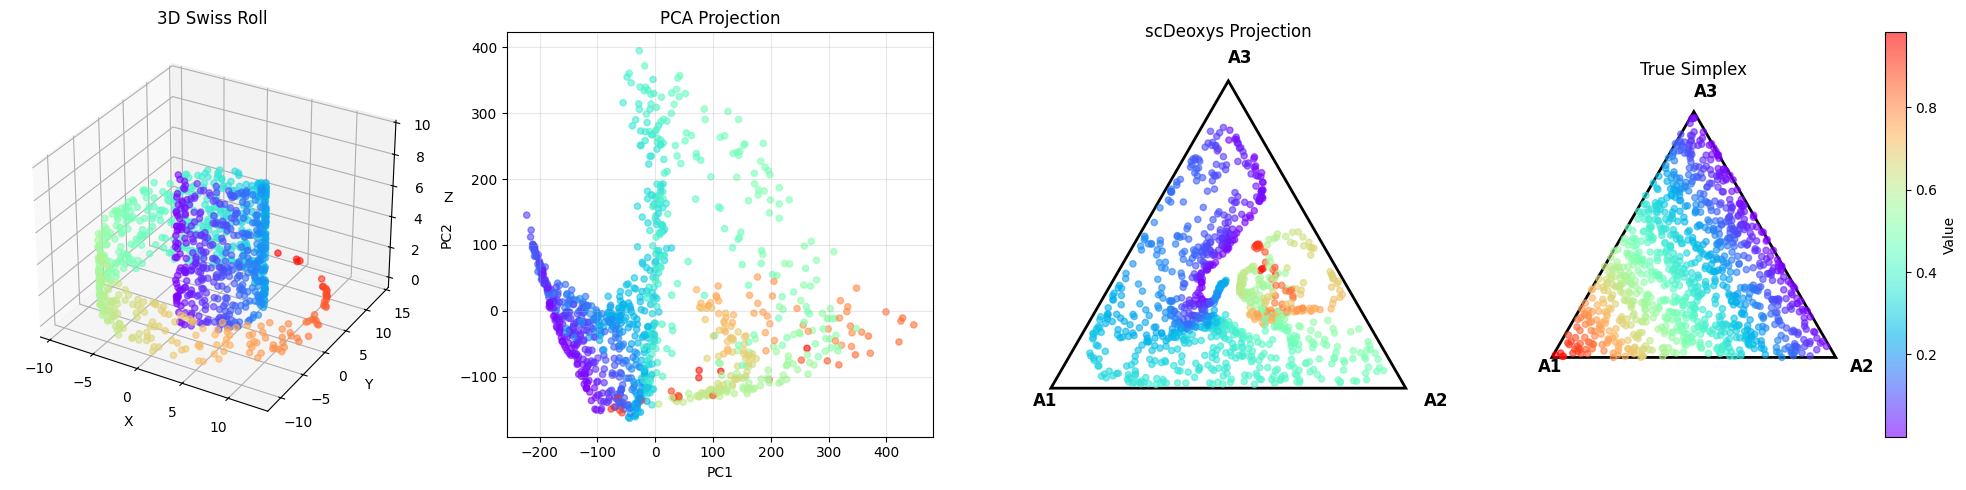

In [18]:
# 绘制对比图
print("正在生成对比图...")
fig2 = plot_comparison(adata)
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
print("✓ Comparison plot saved to comparison.png")
plt.show()

## 完成！

所有步骤已完成。您可以：
- 检查生成的图像文件（training_curves.png 和 comparison.png）
- 查看 metrics.json 文件中的详细指标
- 修改参数重新运行以探索不同的结果